# ChestX-ray14 — ResNet-50 vs Vision Transformer (Built From Scratch)
**University of Hertfordshire | Multi-Modal Medical Diagnosis Agent**

Both architectures are implemented entirely in **pure PyTorch**

This notebook covers:
1. Download images_002 → images_005 from Kaggle
2. Data augmentation pipeline
3. ResNet-50 built from scratch (BottleneckBlock + skip connections)
4. ViT-B/16 built from scratch (PatchEmbedding + MultiHeadAttention + TransformerBlock)
5. Side-by-side evaluation & comparison


# Install packages

In [3]:
!pip install --upgrade matplotlib seaborn pandas numpy Pillow tqdm scikit-learn
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
print('Packages installed')

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
Packages installed


# Import Required Libraries

In [4]:
import os, json, tarfile, warnings, time, copy, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import roc_auc_score, f1_score

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# Paths
DRIVE_BASE = Path('')
RAW_CX     = DRIVE_BASE / 'data' / 'raw' / 'chestxray'
PROC_CX    = DRIVE_BASE / 'data' / 'processed' / 'chestxray'
IMG_DIR    = RAW_CX / 'images'
CKPT_DIR   = DRIVE_BASE / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

# Constants
TARGET = ['Cardiomegaly','Effusion','Pneumonia','Consolidation','Edema',
          'Pneumothorax','Infiltration','Atelectasis','Nodule','Mass',
          'Pleural_Thickening','Emphysema','Fibrosis','Hernia','No Finding']
IMG_SIZE    = 224
SCALE_FACTOR = 1
BATCH_SIZE  = 32 * SCALE_FACTOR

NUM_EPOCHS  = 30
LR          = 3e-4 * (SCALE_FACTOR ** 0.5)
RANDOM_SEED = 42
NUM_WORKERS = 0

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None — switch to T4 GPU!"}')

C:\Users\vo25aag\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Device : cuda
GPU    : NVIDIA GeForce RTX 4060


In [5]:
NUM_WORKERS, LR

(0, 0.0003)

In [10]:
IMG_DIR = Path('images')
all_imgs = list(IMG_DIR.rglob('*.png'))
print(f'\nTotal images available: {len(all_imgs):,}')


Total images available: 112,120



## Data Augmentation Pipeline

In [11]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Kept so the Dataset cell's caching still works.
CACHE_SIZE = 256

train_transform = transforms.Compose([
    # Self-contained crop: resizes internally, so it behaves correctly
    # whether it's handed a full-res 1024px X-ray or a cached image.
    # scale=(0.85, 1.0) keeps at least 85% of the area → whole thorax
    # always stays in frame (no shoulder/rib-corner crops), while still
    # giving real zoom/crop diversity. ratio near 1.0 avoids stretching.
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Augmentation pipeline defined')
print(f'  Train : {len(train_transform.transforms)} steps')
print(f'  Val   : {len(val_transform.transforms)} steps')

Augmentation pipeline defined
  Train : 7 steps
  Val   : 3 steps


## Visualise augmentation examples

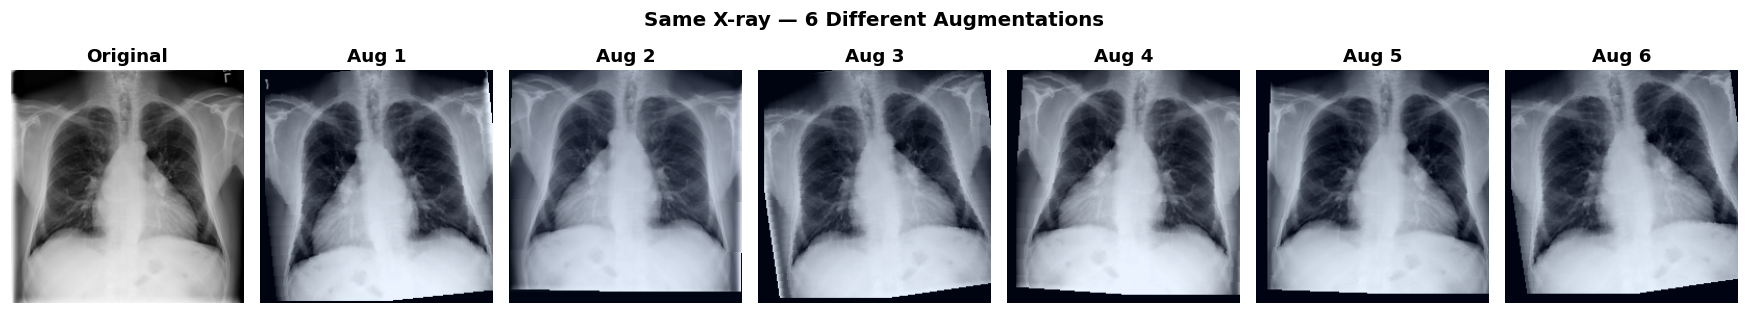

In [12]:
def show_augmentations(img_dir, n=6):
    imgs = list(img_dir.rglob('*.png'))
    if not imgs:
        print('No images found — run Cell 6 first'); return
    src = Image.open(imgs[0]).convert('RGB')
    fig, axes = plt.subplots(1, n + 1, figsize=(16, 3))
    axes[0].imshow(src.resize((224, 224)), cmap='gray')
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')
    for i in range(1, n + 1):
        aug = train_transform(src).permute(1, 2, 0).numpy()
        aug = (aug - aug.min()) / (aug.max() - aug.min())
        axes[i].imshow(aug, cmap='gray')
        axes[i].set_title(f'Aug {i}', fontweight='bold')
        axes[i].axis('off')
    fig.suptitle('Same X-ray — 6 Different Augmentations', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_augmentations(IMG_DIR)

## Dataset class

In [13]:

def encode_labels(label_str, target=TARGET):
    """Multi-hot encode a pipe-separated label string into a float32 vector."""
    labels = set(l.strip() for l in label_str.split('|'))
    return [1.0 if t in labels else 0.0 for t in target]


# Build disk index ONCE, shared across all three datasets
print('Indexing images on disk (one-time scan)...')
_t = time.time()
IMG_INDEX = {p.name: str(p) for p in Path(IMG_DIR).rglob('*.png')}
print(f'  {len(IMG_INDEX):,} images indexed in {time.time()-_t:.1f}s')


class ChestXrayDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, img_index=IMG_INDEX, cache=True):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform

        label_matrix = self.df['Finding Labels'].apply(encode_labels).tolist()
        self.labels  = torch.tensor(label_matrix, dtype=torch.float32)

        self.df['img_path'] = self.df['Image Index'].map(img_index)
        valid        = self.df['img_path'].notna()
        self.df      = self.df[valid].reset_index(drop=True)
        self.labels  = self.labels[valid.values]
        self.paths   = self.df['img_path'].tolist()
        print(f'  {Path(csv_path).name}: {len(self.df):,} images matched')

        # Pre-cache images in RAM 
        self.cache = {}
        if cache:
            print(f'  Caching {len(self.paths):,} images in RAM...')
            for i, p in enumerate(tqdm(self.paths, leave=False)):
                self.cache[i] = Image.open(p).convert('RGB').resize(
                    (CACHE_SIZE, CACHE_SIZE), Image.BILINEAR
                )
            print(f'Cache ready')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = self.cache[idx] if self.cache else Image.open(self.paths[idx]).convert('RGB')
        # img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


print('\nLoading datasets...')
train_ds = ChestXrayDataset(PROC_CX / 'train.csv', IMG_DIR, train_transform)
val_ds   = ChestXrayDataset(PROC_CX / 'val.csv',   IMG_DIR, val_transform)
test_ds  = ChestXrayDataset(PROC_CX / 'test.csv',  IMG_DIR, val_transform)
print(f'\nTrain: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')

Indexing images on disk (one-time scan)...
  112,120 images indexed in 0.3s

Loading datasets...
  train.csv: 78,566 images matched
  Caching 78,566 images in RAM...


  0%|          | 0/78566 [00:00<?, ?it/s]

Cache ready
  val.csv: 17,063 images matched
  Caching 17,063 images in RAM...


  0%|          | 0/17063 [00:00<?, ?it/s]

Cache ready
  test.csv: 16,491 images matched
  Caching 16,491 images in RAM...


  0%|          | 0/16491 [00:00<?, ?it/s]

Cache ready

Train: 78,566  |  Val: 17,063  |  Test: 16,491


## Patient-level split sanity check
ChestX-ray14 has multiple images per patient. If the same patient appears in
more than one split, val/test AUC is **inflated by leakage**. This cell fails
loudly if that happens. (It can only check when the CSVs carry a `Patient ID`
column — if they don't, it warns you to verify the split was made patient-wise.)

In [15]:
def check_patient_leakage(*csv_paths):
    import pandas as pd
    from pathlib import Path
    sets, names = [], []
    for p in csv_paths:
        df = pd.read_csv(p)
        col = next((c for c in df.columns if c.strip().lower() == 'patient id'), None)
        if col is None:
            print(f'  ⚠️  {Path(p).name}: no "Patient ID" column — '
                  f'cannot verify. Make sure the split was done by patient, not by row.')
            return
        sets.append(set(df[col].unique()))
        names.append(Path(p).name)
    leaks = False
    for a in range(len(sets)):
        for b in range(a + 1, len(sets)):
            overlap = sets[a] & sets[b]
            if overlap:
                leaks = True
                print(f'  ❌ LEAKAGE: {len(overlap)} patients shared between '
                      f'{names[a]} and {names[b]} (e.g. {list(overlap)[:5]})')
    if not leaks:
        print('  ✅ No patient overlap across splits — clean split.')

check_patient_leakage(PROC_CX / 'train.csv', PROC_CX / 'val.csv', PROC_CX / 'test.csv')


  ✅ No patient overlap across splits — clean split.


# WeightedRandomSampler + DataLoaders
 Per-sample weight = inverse frequency of its rarest positive label.   
This handles the severe 14-class imbalance (No Finding 60k vs Hernia 227)   
without relying on TARGET column lookups — uses the pre-built label tensors.   

In [16]:
def make_sampler(dataset):
    label_matrix  = dataset.labels.numpy()                  # (N, 15)
    class_counts  = label_matrix.sum(axis=0)                # (15,) positives per class
    class_weights = 1.0 / np.maximum(class_counts, 1)       # inverse freq, avoid div/0

    sample_weights = []
    for row in label_matrix:
        pos_weights = row * class_weights                    # zero out negatives
        # weight = rarest positive class; fall back to min weight if all-negative
        w = pos_weights.max() if pos_weights.max() > 0 else class_weights.min()
        sample_weights.append(w)

    return WeightedRandomSampler(
        torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )


# NOTE: We deliberately do NOT use make_sampler here.
# Combining a WeightedRandomSampler (oversamples rare classes) with
# pos_weight in the loss (up-weights rare positives) double-corrects the
# imbalance — it over-predicts rare findings, hurts calibration, and caps
# mean AUC. We keep ONE mechanism: pos_weight in the loss. make_sampler is
# left defined above only for reference / experimentation.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print('DataLoaders ready')


Train batches : 2456
Val batches   : 534
Test batches  : 516
DataLoaders ready


# Asymmetric Loss

## Loss Function
BCEWithLogitsLoss with pos_weight balances per-class imbalance.   
pos_weight[i] = neg_count[i] / pos_count[i]: the loss for a positive   
example of class i is scaled up proportionally to how rare it is,   
so Hernia (227 samples) is penalised ~263× more than No Finding (60k).   

In [17]:
def compute_pos_weight(dataset, device):
    """Compute per-class pos_weight = neg_count / pos_count for BCEWithLogitsLoss."""
    label_matrix = dataset.labels.numpy()          # (N, 15)
    pos_counts   = label_matrix.sum(axis=0)        # positives per class
    neg_counts   = len(label_matrix) - pos_counts  # negatives per class
    pos_weight   = neg_counts / np.maximum(pos_counts, 1)  # avoid div/0
    # Cap extreme weights. Raw Hernia weight is ~263x, which (now that
    # pos_weight is the ONLY imbalance correction) makes the loss explode on
    # the few confident-wrong rare cases. Capping at 20 keeps rare classes
    # boosted without destabilising training / wrecking calibration.
    pos_weight   = np.minimum(pos_weight, 20.0)
    return torch.tensor(pos_weight, dtype=torch.float32).to(device)


pos_weight = compute_pos_weight(train_ds, DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print('BCEWithLogitsLoss with pos_weight ready')
print(f'  pos_weight range: {pos_weight.min():.1f} (No Finding) → {pos_weight.max():.1f} (capped at 20)')
print(f'  Classes: {list(zip(TARGET, pos_weight.cpu().numpy().round(1)))}')


BCEWithLogitsLoss with pos_weight ready
  pos_weight range: 0.9 (No Finding) → 20.0 (capped at 20)
  Classes: [('Cardiomegaly', np.float32(20.0)), ('Effusion', np.float32(7.3)), ('Pneumonia', np.float32(20.0)), ('Consolidation', np.float32(20.0)), ('Edema', np.float32(20.0)), ('Pneumothorax', np.float32(19.8)), ('Infiltration', np.float32(4.7)), ('Atelectasis', np.float32(8.6)), ('Nodule', np.float32(16.7)), ('Mass', np.float32(17.4)), ('Pleural_Thickening', np.float32(20.0)), ('Emphysema', np.float32(20.0)), ('Fibrosis', np.float32(20.0)), ('Hernia', np.float32(20.0)), ('No Finding', np.float32(0.9))]


# ResNet-50 — Built From Scratch

In [18]:
class BottleneckBlock(nn.Module):
    """
    ResNet-50 Bottleneck block:
      1×1 conv (squeeze)  →  3×3 conv (spatial)  →  1×1 conv (expand)
      + skip connection (identity or projected)
    expansion=4 means output channels = 4 × mid_channels
    """
    expansion = 4

    def __init__(self, in_ch, mid_ch, stride=1, downsample=None):
        super().__init__()
        # 1×1 squeeze
        self.conv1 = nn.Conv2d(in_ch, mid_ch, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid_ch)
        # 3×3 spatial
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(mid_ch)
        # 1×1 expand
        self.conv3 = nn.Conv2d(mid_ch, mid_ch * self.expansion, kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(mid_ch * self.expansion)
        self.relu  = nn.ReLU(inplace=True)
        # downsample adjusts skip connection when dimensions change
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResNet50(nn.Module):
    """
    ResNet-50 built entirely from scratch.
    Layer config: [3, 4, 6, 3] bottleneck blocks.
    Input : (B, 3, 224, 224)
    Output: (B, num_classes)  — raw logits, no sigmoid
    """
    def __init__(self, num_classes=6):
        super().__init__()
        self.in_ch = 64

        # ── Stem ──────────────────────────────────────────────
        self.conv1   = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ── 4 residual stages ─────────────────────────────────
        # Stage 1: 3 blocks, mid=64,  output=256,  stride=1
        # Stage 2: 4 blocks, mid=128, output=512,  stride=2
        # Stage 3: 6 blocks, mid=256, output=1024, stride=2
        # Stage 4: 3 blocks, mid=512, output=2048, stride=2
        self.layer1 = self._make_layer(64,  n=3, stride=1)
        self.layer2 = self._make_layer(128, n=4, stride=2)
        self.layer3 = self._make_layer(256, n=6, stride=2)
        self.layer4 = self._make_layer(512, n=3, stride=2)

        # ── Head ──────────────────────────────────────────────
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))   # → (B, 2048, 1, 1)
        self.head    = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(512 * BottleneckBlock.expansion, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )
        self._init_weights()

    def _make_layer(self, mid_ch, n, stride):
        out_ch     = mid_ch * BottleneckBlock.expansion
        downsample = None
        if stride != 1 or self.in_ch != out_ch:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        layers    = [BottleneckBlock(self.in_ch, mid_ch, stride, downsample)]
        self.in_ch = out_ch
        for _ in range(1, n):
            layers.append(BottleneckBlock(self.in_ch, mid_ch))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.head(x)


resnet_model = ResNet50(num_classes=len(TARGET)).to(DEVICE)
total     = sum(p.numel() for p in resnet_model.parameters())
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print('ResNet-50 (built from scratch — no torchvision.models)')
print(f'  Total parameters     : {total:,}')
print(f'  Trainable parameters : {trainable:,}')
print(f'  Stages               : [3, 4, 6, 3] bottleneck blocks')
print(f'  Feature map at head  : 2048-dim')

ResNet-50 (built from scratch — no torchvision.models)
  Total parameters     : 24,564,815
  Trainable parameters : 24,564,815
  Stages               : [3, 4, 6, 3] bottleneck blocks
  Feature map at head  : 2048-dim


In [11]:
class PatchEmbedding(nn.Module):
    """
    Splits a 224×224 image into 196 non-overlapping 16×16 patches,
    then linearly projects each patch to a 768-dim embedding vector.

    Trick: Conv2d with kernel_size=patch_size and stride=patch_size
    does the split + linear projection in a single operation.
    """
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=768):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2          # 14×14 = 196
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)          # (B, 768, 14, 14)
        x = x.flatten(2)          # (B, 768, 196)
        x = x.transpose(1, 2)     # (B, 196, 768)
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Scaled dot-product multi-head self-attention.
    12 heads × 64 dim = 768 total.  Scale = 1/√64.
    """
    def __init__(self, embed_dim=768, num_heads=12, attn_drop=0.1, proj_drop=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads     # 64
        self.scale     = self.head_dim ** -0.5      # 1/√64

        # Single linear layer projects input to Q, K, V all at once
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        # Project → reshape to (3, B, heads, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)            # each: (B, heads, N, head_dim)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))

        # Weighted sum of values, reshape back
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))


class MLP(nn.Module):
    """
    Feed-forward block inside each Transformer layer.
    768 → 3072 (GELU) → 768
    """
    def __init__(self, embed_dim=768, mlp_ratio=4, drop=0.1):
        super().__init__()
        hidden    = int(embed_dim * mlp_ratio)   # 3072
        self.fc1  = nn.Linear(embed_dim, hidden)
        self.act  = nn.GELU()
        self.fc2  = nn.Linear(hidden, embed_dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class TransformerBlock(nn.Module):
    """
    One Transformer encoder layer:
      x = x + Attention(LayerNorm(x))
      x = x + MLP(LayerNorm(x))
    """
    def __init__(self, embed_dim=768, num_heads=12, mlp_ratio=4,
                 attn_drop=0.1, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, attn_drop, drop)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = MLP(embed_dim, mlp_ratio, drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # attention residual
        x = x + self.mlp(self.norm2(x))    # MLP residual
        return x


class VisionTransformer(nn.Module):
    """
    Vision Transformer ViT-B/16 built entirely from scratch.

    B  = Base  →  embed_dim=768, depth=12, heads=12
    /16         →  patch_size=16  →  196 patches per image

    Input : (B, 3, 224, 224)
    Output: (B, num_classes)  — raw logits, no sigmoid
    """
    def __init__(self, img_size=224, patch_size=16, in_ch=3,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4,
                 num_classes=6, attn_drop=0.1, drop=0.1):
        super().__init__()

        # ── Patch embedding ──────────────────────────────────
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_ch, embed_dim)
        num_patches      = self.patch_embed.num_patches   # 196

        # ── Learnable CLS token + positional embedding ───────
        # CLS token is prepended → sequence length = 197
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(drop)

        # ── 12 Transformer encoder blocks ───────────────────
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, attn_drop, drop)
            for _ in range(depth)
        ])

        # ── Classification head on CLS token ────────────────
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B  = x.shape[0]
        x  = self.patch_embed(x)                         # (B, 196, 768)
        cls = self.cls_token.expand(B, -1, -1)           # (B,   1, 768)
        x  = torch.cat([cls, x], dim=1)                  # (B, 197, 768)
        x  = self.pos_drop(x + self.pos_embed)           # add position info
        x  = self.blocks(x)                              # 12 transformer layers
        x  = self.norm(x)
        x  = x[:, 0]                                     # CLS token only
        return self.head(x)                              # (B, num_classes)


vit_model = VisionTransformer(num_classes=len(TARGET)).to(DEVICE)
total     = sum(p.numel() for p in vit_model.parameters())
trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print('Vision Transformer ViT-B/16 (built from scratch — no timm)')
print(f'  Total parameters     : {total:,}')
print(f'  Trainable parameters : {trainable:,}')
print(f'  Patch size           : 16×16')
print(f'  Num patches          : 196   (224÷16=14 → 14×14=196)')
print(f'  Embed dim            : 768')
print(f'  Transformer layers   : 12')
print(f'  Attention heads      : 12   (64 dim each)')

Vision Transformer ViT-B/16 (built from scratch — no timm)
  Total parameters     : 85,810,191
  Trainable parameters : 85,810,191
  Patch size           : 16×16
  Num patches          : 196   (224÷16=14 → 14×14=196)
  Embed dim            : 768
  Transformer layers   : 12
  Attention heads      : 12   (64 dim each)


# Training Pipeline

In [22]:
# Training & evaluation functions

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):        # mixed precision
            loss = criterion(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits       = model(imgs)
        total_loss  += criterion(logits, labels).item()
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    aucs   = []
    for i in range(labels.shape[1]):
        if labels[:, i].sum() > 0:
            aucs.append(roc_auc_score(labels[:, i], probs[:, i]))
        else:
            aucs.append(float('nan'))
    mean_auc = np.nanmean(aucs)
    return total_loss / len(loader), mean_auc, aucs, probs, labels


def train_model(model, name, train_loader, val_loader,
                criterion, epochs, lr, device, ckpt_dir,
                warmup_epochs=5, resume_from=None):
    """
    Train a model with warmup + cosine LR, mixed precision, AUC-based
    checkpointing and early stopping.

    Two checkpoints are written:
      * {name}_best.pth  — weights only, the best-AUC model (for deployment)
      * {name}_full.pth  — full state (model+optimizer+scheduler+scaler+epoch),
                           overwritten EVERY epoch, for exact resume.

    Pass resume_from=ckpt_dir/'{name}_full.pth' to continue an interrupted run
    bit-for-bit (optimizer momentum, LR position and epoch all restored).
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    warmup = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0,
        total_iters=warmup_epochs)
    cosine = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs - warmup_epochs)
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine],
        milestones=[warmup_epochs])

    scaler  = torch.amp.GradScaler('cuda')
    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'lr': []}
    best_auc, best_weights = 0.0, None
    patience_cnt, patience = 0, 17
    start_epoch = 1

    # ── Resume from a full checkpoint if requested ───────────────────────
    if resume_from is not None and Path(resume_from).exists():
        ckpt = torch.load(resume_from, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
        best_auc    = ckpt.get('best_auc', 0.0)
        history     = ckpt.get('history', history)
        start_epoch = ckpt['epoch'] + 1
        # recover the best weights file if present, else fall back to current
        best_path = ckpt_dir / f'{name}_best.pth'
        best_weights = (torch.load(best_path, map_location=device)
                        if best_path.exists() else copy.deepcopy(model.state_dict()))
        print(f'  ↪️  Resumed {name} from epoch {ckpt["epoch"]} '
              f'(best AUC so far: {best_auc:.4f})')

    print(f'\n{"═"*55}')
    print(f'  Training {name}')
    print(f'{"═"*55}')

    for epoch in range(start_epoch, epochs + 1):
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss, val_auc, _, _, _ = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['lr'].append(current_lr)

        print(f'  Epoch {epoch:02d}/{epochs} | '
              f'Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | '
              f'Val AUC {val_auc:.4f} | LR {current_lr:.2e} | {time.time()-t0:.0f}s')

        if val_auc > best_auc:
            best_auc     = val_auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, ckpt_dir / f'{name}_best.pth')
            print(f'         ✅ New best AUC: {best_auc:.4f} — saved')
            patience_cnt = 0
        else:
            patience_cnt += 1

        # Full resume checkpoint — written EVERY epoch (overwrites), so an
        # interrupted run can always resume from the last completed epoch,
        # not just the last AUC improvement.
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'scaler':    scaler.state_dict(),
            'best_auc':  best_auc,
            'history':   history,
        }, ckpt_dir / f'{name}_full.pth')

        if patience_cnt >= patience:
            print(f'\n  ⏹️  Early stopping at epoch {epoch}')
            break

    # Guard: best_weights can be None if a resumed run never beat its prior
    # best — in that case keep the already-loaded weights.
    if best_weights is not None:
        model.load_state_dict(best_weights)
    print(f'\n  ✅ {name} done | Best Val AUC: {best_auc:.4f}')
    return model, history


print('Training functions defined')


Training functions defined


# Train ResNet-50

In [ ]:
# resnet_model, resnet_history = train_model(
#     model        = resnet_model,
#     name         = 'ResNet50',
#     train_loader = train_loader,
#     val_loader   = val_loader,
#     criterion    = criterion,
#     epochs       = NUM_EPOCHS,
#     lr           = LR,
#     device       = DEVICE,
#     ckpt_dir     = CKPT_DIR,
#     warmup_epochs=5
# )


# RESUME an interrupted, re-create resnet_model with the
# same architecture, then pass the full checkpoint. Warmup is skipped
# automatically because the scheduler position is restored:
#
resnet_model, resnet_history = train_model(
    model=resnet_model, name='ResNet50',
    train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, epochs=NUM_EPOCHS, lr=LR,
    device=DEVICE, ckpt_dir=CKPT_DIR, warmup_epochs=5,
    resume_from=CKPT_DIR / 'ResNet50_full.pth')


  ↪️  Resumed ResNet50 from epoch 26 (best AUC so far: 0.7936)

═══════════════════════════════════════════════════════
  Training ResNet50
═══════════════════════════════════════════════════════


  Train:   0%|          | 0/2456 [00:00<?, ?it/s]

  Epoch 27/30 | Train Loss 0.7541 | Val Loss 0.7641 | Val AUC 0.7933 | LR 1.86e-05 | 634s


  Train:   0%|          | 0/2456 [00:00<?, ?it/s]

  Epoch 28/30 | Train Loss 0.7526 | Val Loss 0.7629 | Val AUC 0.7946 | LR 1.05e-05 | 690s
         ✅ New best AUC: 0.7946 — saved


  Train:   0%|          | 0/2456 [00:00<?, ?it/s]

  Epoch 29/30 | Train Loss 0.7499 | Val Loss 0.7614 | Val AUC 0.7952 | LR 4.71e-06 | 594s
         ✅ New best AUC: 0.7952 — saved


  Train:   0%|          | 0/2456 [00:00<?, ?it/s]

  Epoch 30/30 | Train Loss 0.7483 | Val Loss 0.7628 | Val AUC 0.7955 | LR 1.18e-06 | 751s
         ✅ New best AUC: 0.7955 — saved

  ✅ ResNet50 done | Best Val AUC: 0.7955


# Evaluation

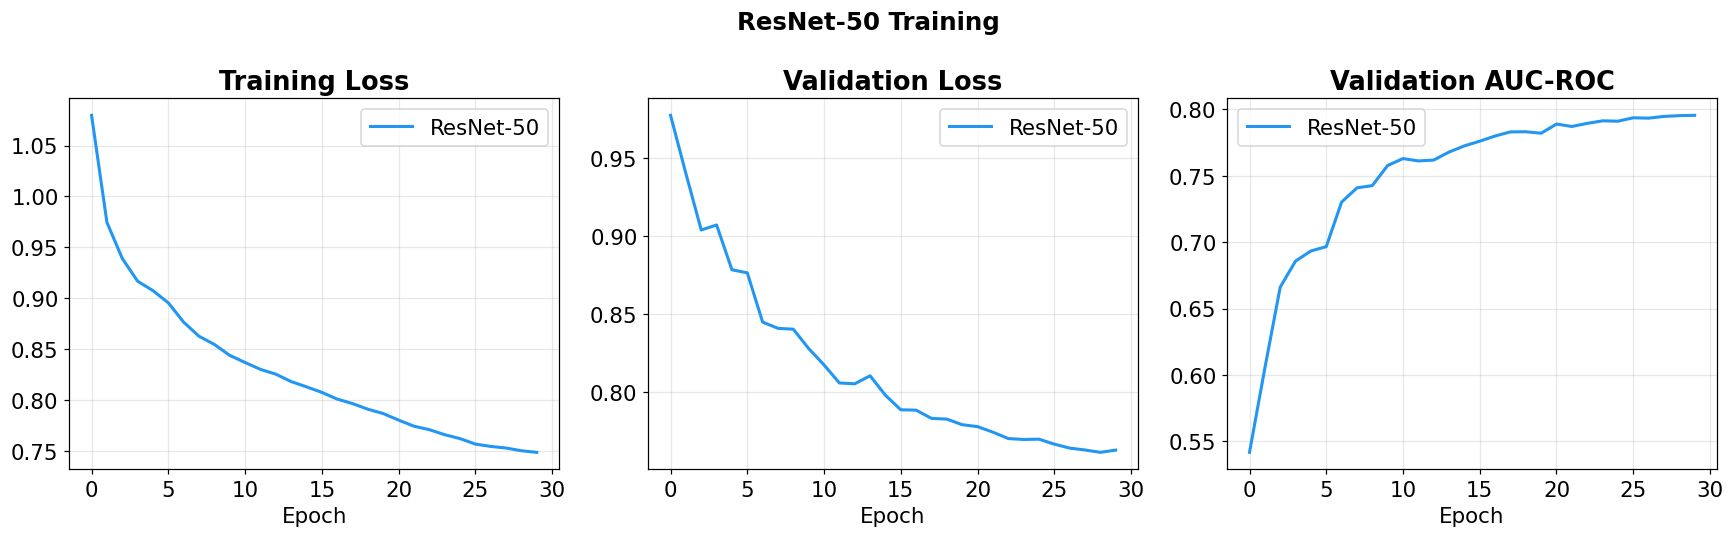

In [51]:
plt.close('all')
plt.rcParams.update({'font.size': 14})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
C = {'ResNet-50': '#2196F3'}

for ax, key, title in zip(
    axes,
    ['train_loss', 'val_loss', 'val_auc'],
    ['Training Loss', 'Validation Loss', 'Validation AUC-ROC']
):
    ax.plot(resnet_history[key], label='ResNet-50', color=C['ResNet-50'], linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('ResNet-50 Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Test set evaluation
print('Evaluating on TEST set ...')
_, resnet_auc, resnet_aucs, resnet_probs, resnet_labels = evaluate(
    resnet_model, test_loader, criterion, DEVICE)

print(f'\n  ResNet-50  Mean AUC : {resnet_auc:.4f}')

Evaluating on TEST set ...

  ResNet-50  Mean AUC : 0.7893


In [34]:
# Per-class AUC table
def fmt(v):
    return round(v, 4) if not np.isnan(v) else 'N/A'

def winner(r, v):
    if r == 'N/A' or v == 'N/A': return '-'
    return '🔵 ResNet' if r > v else '🔴 ViT' if v > r else '🟡 Tie'

rows = []
for cond, r in zip(TARGET, resnet_aucs):
    rf = fmt(r)
    rows.append({'Condition': cond, 'ResNet-50 AUC': rf})

rows.append({
    'Condition':     'MEAN',
    'ResNet-50 AUC': round(resnet_auc, 4),
})

results_df = pd.DataFrame(rows)
print('Per-condition AUC-ROC — Test Set')
print('=' * 60)
display(results_df)
results_df.to_csv('model_result.csv', index=False)

Per-condition AUC-ROC — Test Set


,Condition,ResNet-50 AUC
0,Cardiomegaly,0.9089
1,Effusion,0.8605
2,Pneumonia,0.7287
3,Consolidation,0.7854
4,Edema,0.8914
5,Pneumothorax,0.8408
6,Infiltration,0.6775
7,Atelectasis,0.7646
8,Nodule,0.6898
9,Mass,0.7866


In [ ]:
#  Per-class AUC bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(TARGET)), 0.35
r_aucs = [a if not np.isnan(a) else 0 for a in resnet_aucs]

b1 = ax.bar(x - w/2, r_aucs, w, label='ResNet-50', color='#2196F3', edgecolor='white')

ax.set_title('Per-Condition AUC-ROC — ResNet-50',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AUC-ROC Score')
ax.set_xticks(x)
ax.set_xticklabels(TARGET, rotation=90, ha='right')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')

for bar in list(b1):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
#  F1 scores at threshold 0.5
def compute_f1(probs, labels, thr=0.5):
    preds = (probs >= thr).astype(int)
    f1s   = []
    for i in range(labels.shape[1]):
        if labels[:, i].sum() > 0:
            f1s.append(f1_score(labels[:, i], preds[:, i], zero_division=0))
        else:
            f1s.append(float('nan'))
    return f1s, np.nanmean(f1s)

r_f1s, r_mean_f1 = compute_f1(resnet_probs, resnet_labels)

print(f'{"Condition":<22} {"ResNet-50":>12}')
print('-' * 48)
for cond, rf in zip(TARGET, r_f1s):
    print(f'{cond:<22} {rf:>12.4f}')
print('-' * 48)
print(f'{"MEAN":<22} {r_mean_f1:>12.4f}')

Condition                 ResNet-50
------------------------------------------------
Cardiomegaly                 0.2882
Effusion                     0.4398
Pneumonia                    0.0485
Consolidation                0.1780
Edema                        0.1985
Pneumothorax                 0.2405
Infiltration                 0.3803
Atelectasis                  0.3090
Nodule                       0.1778
Mass                         0.2117
Pleural_Thickening           0.1509
Emphysema                    0.2063
Fibrosis                     0.1117
Hernia                       0.0000
No Finding                   0.7166
------------------------------------------------
MEAN                         0.2439


In [40]:
# Final summary card

r_params = sum(p.numel() for p in resnet_model.parameters())

print('=' * 55)
print('         FINAL SUMMARY')
print('=' * 55)
print(f'  Metric            ResNet-50')
print(f'  Mean AUC-ROC    {resnet_auc:>10.4f}')
print(f'  Mean F1 Score   {r_mean_f1:>10.4f}')
print(f'  Parameters      {r_params:>10,}')

         FINAL SUMMARY
  Metric            ResNet-50
  Mean AUC-ROC        0.7893
  Mean F1 Score       0.2439
  Parameters      24,564,815



## What I'd do

Add the threshold tuning + a fuller F1 picture to notebook 1 (it already exists in the timm one). Roughly:

```python
from sklearn.metrics import precision_recall_fscore_support

def tuned_thresholds(y, p):
    th = np.full(y.shape[1], 0.5)
    for i in range(y.shape[1]):
        if y[:, i].sum() == 0: continue
        f1s = [precision_recall_fscore_support(y[:, i], (p[:, i] >= t).astype(int),
               average='binary', zero_division=0)[2] for t in np.linspace(0.05, 0.95, 19)]
        th[i] = np.linspace(0.05, 0.95, 19)[int(np.argmax(f1s))]
    return th

th = tuned_thresholds(val_labels, val_probs)          # tune on VAL
preds = (resnet_probs >= th).astype(int)               # apply to TEST
for avg in ['macro', 'micro', 'weighted', 'samples']:
    f1 = precision_recall_fscore_support(resnet_labels, preds, average=avg, zero_division=0)[2]
    print(f'{avg:9s} F1: {f1:.4f}')
```

Report micro/weighted alongside macro — they're legitimate and much higher. And consider reporting F1 on just the clinically relevant frequent classes (Cardiomegaly, Effusion, Edema), where it's both higher and more meaningful.

One bonus point relevant to the abstract: your "mean AUC" includes **No Finding** as a 15th label, but No Finding isn't a pathology and the CheXNet 0.841 benchmark is over the 14 pathologies only. If you exclude No Finding, ViT's 14-pathology test mean AUC is ~**0.821** — directly comparable to CheXNet and cleanly above your 0.82 target.

Two notebook-hygiene notes (not the cause): the timm notebook won't run top-to-bottom as saved — `test_ds` (cell 12) and `train_loader`/`test_loader` (cell 16) are commented out, though your run clearly had them defined since the outputs exist.

Want me to update the abstract off the back of this? Specifically I could: switch the figures to test-set numbers, report the 14-pathology AUC (~0.821 for ViT), add a fair F1 (micro/weighted, or the cardiovascular-subset) with the imbalance caveat, and drop the "validation-only" limitation since you do have test results.